In [4]:
from modeling.data_joiner import StockDataJoiner
from modeling.feature_selector import FeatureSelector

In [5]:
# 예시 : 삼성전자
joiner = StockDataJoiner()
selector = FeatureSelector()

# 삼성전자 데이터셋 한 방에 가져오기
df = joiner.get_modeling_dataset('삼성전자', start_date='2023-01-01', end_date='2026-03-05')

c:\Users\최병규\OneDrive\바탕 화면\최종 프로젝트\fin-stock-prediction\modeling\data_joiner.py:126: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=params)


[삼성전자] 모델링 데이터셋 생성 완료 -> (772, 88)


c:\Users\최병규\OneDrive\바탕 화면\최종 프로젝트\fin-stock-prediction\modeling\data_joiner.py:78: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn, params=[ticker, start_year])


In [6]:
df.tail()

,trade_date,ticker,stock_name,open,high,low,close,volume,foreign_net_amt,inst_net_amt,...,rnd_expense,roe,roa,debt_ratio,shares,market_cap,per,pbr,ebitda,ev_ebitda
767,2026-02-26,005930,삼성전자,206500,219000,206000,218000,30095763,-1663473646250,347837587000,...,10864300000000,0.1868,0.1441,0.2994,5919637922,709764586847800,41.861748,1.87,32308216820000,21.968547
768,2026-02-27,005930,삼성전자,210000,223000,210000,216500,51774768,-4224234828250,329230826750,...,10864300000000,0.1868,0.1441,0.2994,5919637922,709764586847800,41.861748,1.87,32308216820000,21.968547
769,2026-03-03,005930,삼성전자,209500,212500,195100,195100,54879010,-3196726141600,217680314000,...,10864300000000,0.1868,0.1441,0.2994,5919637922,709764586847800,41.861748,1.87,32308216820000,21.968547
770,2026-03-04,005930,삼성전자,184200,195900,171900,172200,89427954,-695276560100,291383446700,...,10864300000000,0.1868,0.1441,0.2994,5919637922,709764586847800,41.861748,1.87,32308216820000,21.968547
771,2026-03-05,005930,삼성전자,195000,199700,188100,191600,53959129,-336092254000,-673468470450,...,10864300000000,0.1868,0.1441,0.2994,5919637922,709764586847800,41.861748,1.87,32308216820000,21.968547


In [7]:
# 단기 모델용 데이터 준비 (20일 예측)
df_s = selector.create_target(df, horizon=20)
X_s, y_s = selector.get_features(df_s, mode='short')

# 중장기 모델용 데이터 준비 (60일 예측)
df_l = selector.create_target(df, horizon=60)
X_l, y_l = selector.get_features(df_l, mode='long')

print(f"단기 모델 피쳐 수: {len(X_s.columns)}")
print(f"중장기 모델 피쳐 수: {len(X_l.columns)}")

단기 모델 피쳐 수: 41
중장기 모델 피쳐 수: 75


c:\Users\최병규\OneDrive\바탕 화면\최종 프로젝트\fin-stock-prediction\modeling\data_joiner.py:126: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=params)
c:\Users\최병규\OneDrive\바탕 화면\최종 프로젝트\fin-stock-prediction\modeling\data_joiner.py:78: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn, params=[ticker, start_year])


[삼성전자] 모델링 데이터셋 생성 완료 -> (773, 88)

[삼성전자] Direct Multi-output (20일) 성능
---------------------------------------------
Fixed Params: {'estimator__n_estimators': 300, 'estimator__max_depth': 5, 'estimator__learning_rate': 0.05, 'estimator__subsample': 0.8, 'estimator__colsample_bytree': 0.8}
1일 ahead MAE : 3,408 KRW
1일 ahead RMSE: 4,853 KRW
1일 ahead MAPE: 3.15%
평균 RMSE(1~20일): 31,042 KRW
방향성 적중률(1일): 44.90%
   ├ 상승장 적중률: 17.58%
   └ 하락장 적중률: 92.59%
평균 방향성 적중률(1~20일): 44.80%

기준일: 2026-03-06
향후 20일 예측 결과 (Direct)
-----------------------------------
2026-03-09 |         178,716 KRW
2026-03-10 |         172,386 KRW
2026-03-11 |         165,380 KRW
2026-03-12 |         161,641 KRW
2026-03-13 |         154,471 KRW
2026-03-16 |         147,377 KRW
2026-03-17 |         145,306 KRW
2026-03-18 |         141,634 KRW
2026-03-19 |         137,451 KRW
2026-03-20 |         134,445 KRW
2026-03-23 |         131,794 KRW
2026-03-24 |         130,227 KRW
2026-03-25 |         126,567 KRW
2026-03-26 |       

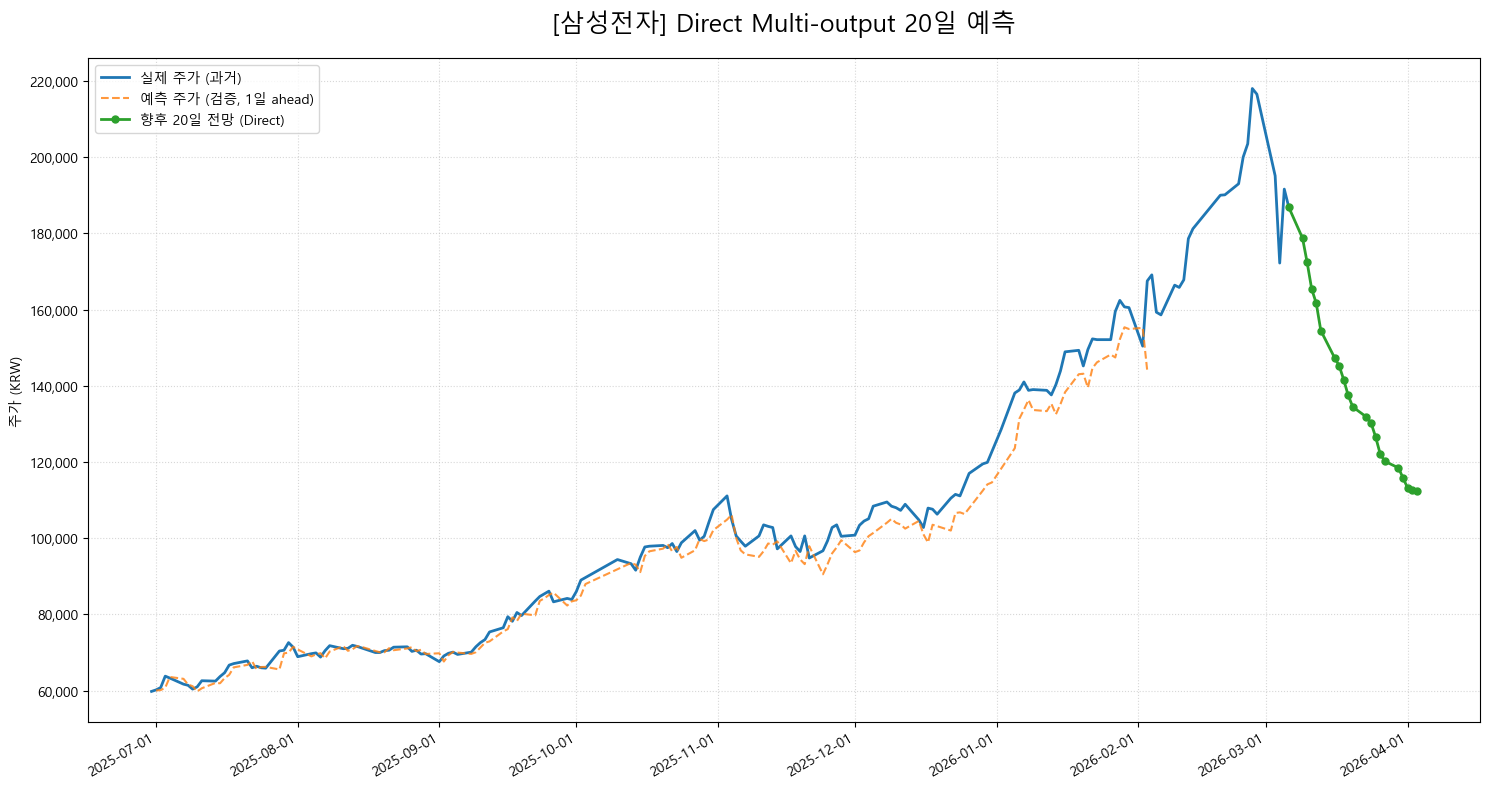

       act_p1        pred_p1    act_r1   pred_r1  act_dir1  pred_dir1  \
606   60200.0   60042.091179  0.006689  0.004048       1.0        1.0   
607   60800.0   60142.653394  0.009967 -0.000953       1.0       -1.0   
608   63800.0   60766.351509  0.049342 -0.000553       1.0       -1.0   
609   63300.0   63588.246202 -0.007837 -0.003319      -1.0       -1.0   
610   61700.0   63095.814192 -0.025276 -0.003226      -1.0       -1.0   
..        ...            ...       ...       ...       ...        ...   
748  162400.0  152178.115427  0.018182 -0.045905       1.0       -1.0   
749  160700.0  155342.026377 -0.010468 -0.043460      -1.0       -1.0   
750  160500.0  154890.372765 -0.001245 -0.036152      -1.0       -1.0   
751  150400.0  155185.937047 -0.062928 -0.033109      -1.0       -1.0   
752  167500.0  143891.700172  0.113697 -0.043273       1.0       -1.0   

     dir_hit1  
606         1  
607         0  
608         0  
609         1  
610         1  
..        ...  
748        

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

from datetime import timedelta
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

from modeling.feature_selector import FeatureSelector
from modeling.data_joiner import StockDataJoiner

plt.rc("font", family="Malgun Gothic")


def add_lags(X: pd.DataFrame, window: int) -> pd.DataFrame:
    """X의 과거 window일치 lag 피처를 한 행으로 펼쳐 생성"""
    return pd.concat([X.shift(lag).add_suffix(f"_lag{lag}") for lag in range(window)], axis=1)


def make_step_rets(close: pd.Series, days: int) -> pd.DataFrame:
    """ret_1..ret_days: 하루 단위 step return 생성"""
    y = {"ret_1": close.shift(-1) / close - 1.0}
    for k in range(2, days + 1):
        y[f"ret_{k}"] = close.shift(-k) / close.shift(-(k - 1)) - 1.0
    return pd.DataFrame(y, index=close.index)


def run_xgb(stock: str, win: int = 20, days: int = 20):
    # 1) 데이터 로드
    joiner = StockDataJoiner()
    selector = FeatureSelector()

    df = joiner.get_modeling_dataset(stock, start_date="2023-01-01", end_date="2026-03-05")
    df = df.replace([np.inf, -np.inf], np.nan).ffill().fillna(0)
    df["trade_date"] = pd.to_datetime(df["trade_date"])
    last_date = pd.to_datetime(df["trade_date"].max())

    if "close" not in df.columns:
        raise ValueError("df에 'close' 컬럼이 없습니다.")

    # 2) 피처 준비 (FeatureSelector 기반)
    df_feat = selector.create_target(df.copy(), horizon=1)
    X_raw, _ = selector.get_features(df_feat, mode="short")

    # 3) 멀티스텝 타깃 생성 (ret_1..ret_days)
    Y_raw = make_step_rets(df["close"], days=days)

    # 4) 피처 정제 + Lag 생성
    drop_cols = ["trade_date", "ticker", "stock_name"]
    X_base = X_raw.drop(columns=[c for c in drop_cols if c in X_raw.columns]).copy()
    X_base = X_base.replace([np.inf, -np.inf], np.nan).ffill().fillna(0)

    X_lag = add_lags(X_base, window=win)

    # 5) X/Y 정렬
    idx = X_lag.dropna().index.intersection(Y_raw.dropna().index)
    X = X_lag.loc[idx]
    Y = Y_raw.loc[idx]

    # 6) Train/Test split (80/20)
    n = len(X)
    split = int(n * 0.8)
    X_tr, X_te = X.iloc[:split], X.iloc[split:]
    Y_tr, Y_te = Y.iloc[:split], Y.iloc[split:]

    if "trade_date" in df_feat.columns:
        te_dates = pd.to_datetime(df_feat.loc[X_te.index, "trade_date"].values)
    else:
        te_dates = pd.to_datetime(X_te.index)

    # 7) 모델 학습 (best params 고정)
    params = {
        "n_estimators": 300,
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "objective": "reg:squarederror",
        "random_state": 42,
    }

    base = XGBRegressor(**params)
    model = MultiOutputRegressor(base, n_jobs=1)
    model.fit(X_tr, Y_tr)

    # 8) 테스트 예측 (수익률)
    pred_ret = model.predict(X_te)
    act_ret = Y_te.values

    # 9) 가격 경로로 환산
    close_t = df.loc[X_te.index, "close"].values.reshape(-1, 1)
    pred_gross = np.cumprod(1.0 + pred_ret, axis=1)
    act_gross = np.cumprod(1.0 + act_ret, axis=1)

    pred_path = close_t * pred_gross
    act_path = close_t * act_gross

    # 10) 성능평가 (1일 ahead 가격 기준)
    pred_p1 = pred_path[:, 0]
    act_p1 = act_path[:, 0]

    rmse1 = np.sqrt(mean_squared_error(act_p1, pred_p1))
    mae1 = mean_absolute_error(act_p1, pred_p1)
    denom = np.clip(act_p1, 1e-9, None)
    mape1 = np.mean(np.abs((act_p1 - pred_p1) / denom)) * 100

    rmse_h = [np.sqrt(mean_squared_error(act_path[:, h], pred_path[:, h])) for h in range(days)]
    rmse_avg = float(np.mean(rmse_h))

    # ---- 방향성 적중률 (Direction Accuracy) ----
    # 1일 ahead 방향 (수익률 부호)
    pred_dir_1 = np.sign(pred_ret[:, 0])
    act_dir_1 = np.sign(act_ret[:, 0])

    dir_acc_1 = np.mean(pred_dir_1 == act_dir_1) * 100

    # 상승/하락 케이스별 적중률
    up_mask = act_dir_1 > 0
    down_mask = act_dir_1 < 0

    up_acc = (np.mean(pred_dir_1[up_mask] == act_dir_1[up_mask]) * 100) if up_mask.any() else np.nan
    down_acc = (np.mean(pred_dir_1[down_mask] == act_dir_1[down_mask]) * 100) if down_mask.any() else np.nan

    # 1~days 전체 평균 방향 적중률 (각 horizon별로 계산 후 평균)
    dir_acc_each = []
    for h in range(days):
        pred_dir_h = np.sign(pred_ret[:, h])
        act_dir_h = np.sign(act_ret[:, h])
        dir_acc_each.append(np.mean(pred_dir_h == act_dir_h) * 100)

    dir_acc_avg = float(np.mean(dir_acc_each))



    print("\n" + "=" * 45)
    print(f"[{stock}] Direct Multi-output ({days}일) 성능")
    print("-" * 45)
    print("Fixed Params:", {f"estimator__{k}": v for k, v in params.items() if k in ["n_estimators","max_depth","learning_rate","subsample","colsample_bytree"]})
    print(f"1일 ahead MAE : {format(int(mae1), ',')} KRW")
    print(f"1일 ahead RMSE: {format(int(rmse1), ',')} KRW")
    print(f"1일 ahead MAPE: {mape1:.2f}%")
    print(f"평균 RMSE(1~{days}일): {format(int(rmse_avg), ',')} KRW")
    print(f"방향성 적중률(1일): {dir_acc_1:.2f}%")
    print(f"   ├ 상승장 적중률: {up_acc:.2f}%")
    print(f"   └ 하락장 적중률: {down_acc:.2f}%")
    print(f"평균 방향성 적중률(1~{days}일): {dir_acc_avg:.2f}%")
    print("=" * 45)

    # 11) 미래 days일 예측
    last_x = X.iloc[[-1]]
    fut_ret = model.predict(last_x)[0]
    last_close = float(df["close"].iloc[-1])

    fut_gross = np.cumprod(1.0 + fut_ret)
    fut_prices = last_close * fut_gross
    fut_dates = pd.date_range(start=last_date + timedelta(days=1), periods=days, freq="B")

    print("\n" + "=" * 35)
    print(f"기준일: {last_date.strftime('%Y-%m-%d')}")
    print(f"향후 {days}일 예측 결과 (Direct)")
    print("-" * 35)
    for d, p in zip(fut_dates, fut_prices):
        print(f"{d.strftime('%Y-%m-%d')} | {format(int(p), ','):>15} KRW")
    print("=" * 35 + "\n")

    # 12) 시각화
    plt.figure(figsize=(15, 8))

    start = pd.to_datetime(te_dates).min()
    df_plot = df.loc[df["trade_date"] >= start]

    plt.plot(pd.to_datetime(df_plot["trade_date"]), df_plot["close"], label="실제 주가 (과거)", linewidth=2)

    te_dates_h1 = pd.to_datetime(df_feat.loc[X_te.index, "trade_date"].values) + pd.offsets.BDay(1)
    plt.plot(te_dates_h1, pred_p1, label="예측 주가 (검증, 1일 ahead)", linestyle="--", linewidth=1.5, alpha=0.8)

    link_dates = [pd.to_datetime(df["trade_date"].iloc[-1])] + list(fut_dates)
    link_prices = [last_close] + list(fut_prices)
    plt.plot(link_dates, link_prices, label=f"향후 {days}일 전망 (Direct)", marker="o", markersize=5, linewidth=2)

    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ",")))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.gcf().autofmt_xdate()

    plt.title(f"[{stock}] Direct Multi-output {days}일 예측", fontsize=18, pad=20)
    plt.ylabel("주가 (KRW)")
    plt.legend(loc="upper left")
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 13) 결과 테이블
    res = pd.DataFrame(
        {
            "act_p1": act_p1,
            "pred_p1": pred_p1,
            "act_r1": act_ret[:, 0],
            "pred_r1": pred_ret[:, 0],
            "act_dir1": np.sign(act_ret[:, 0]),
            "pred_dir1": np.sign(pred_ret[:, 0]),
            "dir_hit1": (np.sign(act_ret[:, 0]) == np.sign(pred_ret[:, 0])).astype(int),
        },
        index=Y_te.index,
    )
    print(res)

    
    return model, res, (fut_dates, fut_prices)


if __name__ == "__main__":
    run_xgb("삼성전자", win=20, days=20)

c:\Users\최병규\OneDrive\바탕 화면\최종 프로젝트\fin-stock-prediction\modeling\data_joiner.py:126: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=params)
c:\Users\최병규\OneDrive\바탕 화면\최종 프로젝트\fin-stock-prediction\modeling\data_joiner.py:78: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn, params=[ticker, start_year])


[삼성전자] 모델링 데이터셋 생성 완료 -> (773, 88)

[삼성전자] Log-Return Multi-output (20일) 성능
---------------------------------------------
1일 ahead MAE : 3,476 KRW
1일 ahead RMSE: 4,950 KRW
1일 ahead MAPE: 3.20%
평균 RMSE(1~20일): 16,830 KRW
방향성 적중률(1일): 40.14%

기준일: 2026-03-06
향후 20일 예측 결과 (Log-Return)
-----------------------------------
2026-03-09 |         180,332 KRW
2026-03-10 |         175,493 KRW
2026-03-11 |         171,294 KRW
2026-03-12 |         176,649 KRW
2026-03-13 |         181,616 KRW
2026-03-16 |         180,915 KRW
2026-03-17 |         187,360 KRW
2026-03-18 |         188,585 KRW
2026-03-19 |         183,316 KRW
2026-03-20 |         184,929 KRW
2026-03-23 |         179,718 KRW
2026-03-24 |         175,433 KRW
2026-03-25 |         170,227 KRW
2026-03-26 |         168,237 KRW
2026-03-27 |         168,253 KRW
2026-03-30 |         166,397 KRW
2026-03-31 |         162,998 KRW
2026-04-01 |         165,703 KRW
2026-04-02 |         165,662 KRW
2026-04-03 |         160,573 KRW



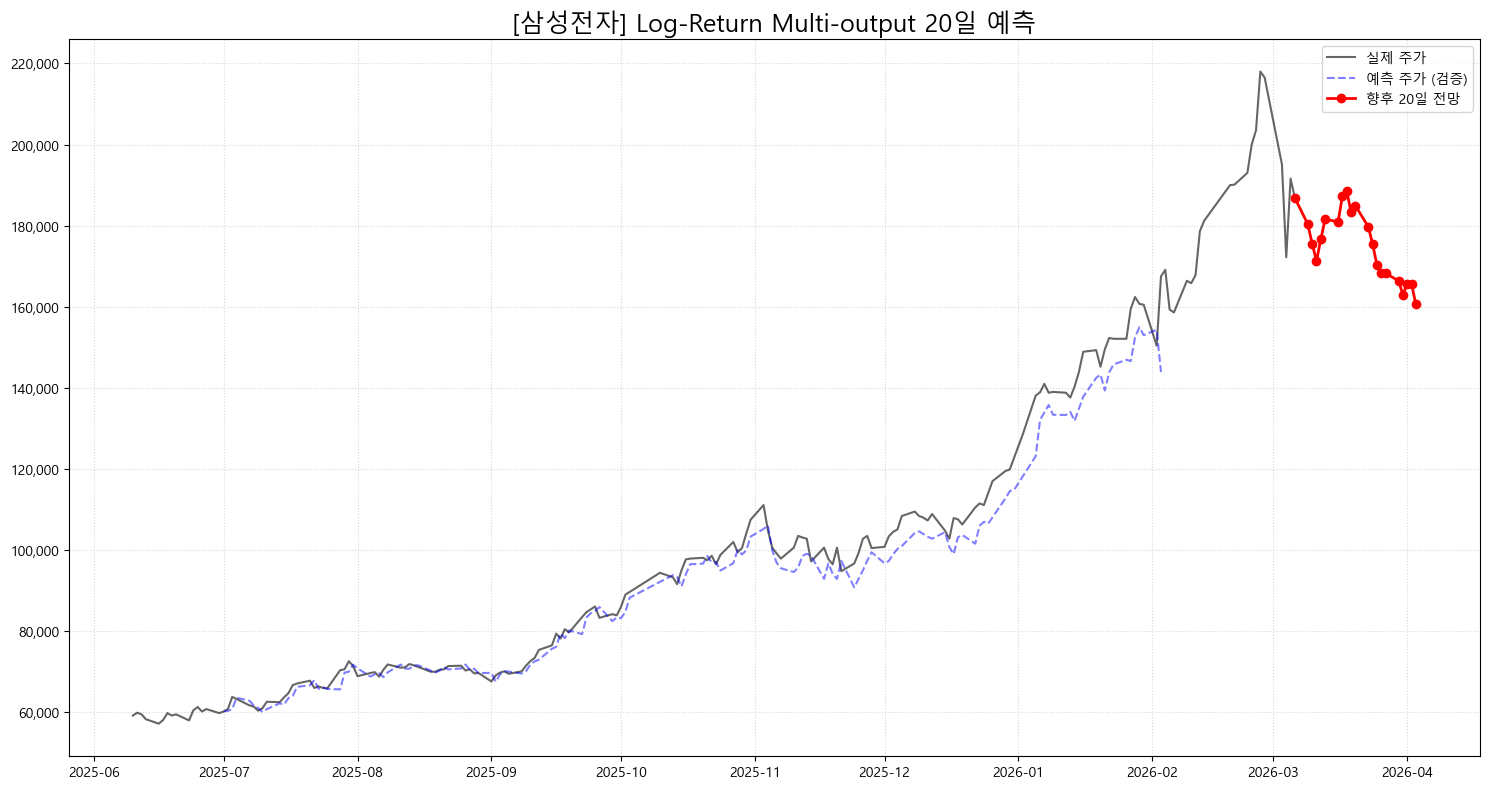

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

from datetime import timedelta
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

from modeling.feature_selector import FeatureSelector
from modeling.data_joiner import StockDataJoiner

plt.rc("font", family="Malgun Gothic")

def add_lags(X: pd.DataFrame, window: int) -> pd.DataFrame:
    """X의 과거 window일치 lag 피처를 한 행으로 펼쳐 생성"""
    return pd.concat([X.shift(lag).add_suffix(f"_lag{lag}") for lag in range(window)], axis=1)

def make_log_rets(close: pd.Series, days: int) -> pd.DataFrame:
    """현재 시점(t) 대비 t+1..t+days의 누적 로그 수익률 생성 (오차 누적 방지)"""
    y = {}
    for k in range(1, days + 1):
        # log(P_{t+k} / P_t)
        y[f"ret_{k}"] = np.log(close.shift(-k) / close)
    return pd.DataFrame(y, index=close.index)

def run_xgb(stock: str, win: int = 20, days: int = 20):
    # 1) 데이터 로드
    joiner = StockDataJoiner()
    selector = FeatureSelector()

    df = joiner.get_modeling_dataset(stock, start_date="2023-01-01")
    df = df.replace([np.inf, -np.inf], np.nan).ffill().fillna(0)
    df["trade_date"] = pd.to_datetime(df["trade_date"])
    last_date = pd.to_datetime(df["trade_date"].max())

    if "close" not in df.columns:
        raise ValueError("df에 'close' 컬럼이 없습니다.")

    # 2) 피처 준비 (FeatureSelector 기반)
    # KeyError 방지를 위해 타겟 하나 생성 후 피처 추출
    df_feat = selector.create_target(df.copy(), horizon=1)
    X_raw, _ = selector.get_features(df_feat, mode="short")

    # 3) [수정] 멀티스텝 타깃 생성 (누적 로그 수익률 기반)
    Y_raw = make_log_rets(df["close"], days=days)

    # 4) 피처 정제 + Lag 생성
    drop_cols = ["trade_date", "ticker", "stock_name", "index"]
    X_base = X_raw.drop(columns=[c for c in drop_cols if c in X_raw.columns]).copy()
    
    # [수정] 인코딩 에러 방지를 위해 컬럼명 영문화
    X_base.columns = [f"f_{i}" for i in range(len(X_base.columns))]
    X_base = X_base.replace([np.inf, -np.inf], np.nan).ffill().fillna(0)

    X_lag = add_lags(X_base, window=win)

    # 5) X/Y 정렬
    idx = X_lag.dropna().index.intersection(Y_raw.dropna().index)
    X = X_lag.loc[idx]
    Y = Y_raw.loc[idx]

    # 6) Train/Test split (80/20)
    n = len(X)
    split = int(n * 0.8)
    X_tr, X_te = X.iloc[:split], X.iloc[split:]
    Y_tr, Y_te = Y.iloc[:split], Y.iloc[split:]

    te_dates = pd.to_datetime(df_feat.loc[X_te.index, "trade_date"].values)

    # 7) 모델 학습 (n_jobs=1 설정으로 에러 방지)
    params = {
        "n_estimators": 300,
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "objective": "reg:squarederror",
        "random_state": 42,
    }

    base = XGBRegressor(**params)
    model = MultiOutputRegressor(base, n_jobs=1) 
    model.fit(X_tr, Y_tr)

    # 8) 테스트 예측 (누적 로그 수익률)
    pred_log_ret = model.predict(X_te)
    act_log_ret = Y_te.values

    # 9) [수정] 가격 경로로 환산 (Exp 함수 사용)
    close_t = df.loc[X_te.index, "close"].values.reshape(-1, 1)
    pred_path = close_t * np.exp(pred_log_ret)
    act_path = close_t * np.exp(act_log_ret)

    # 10) 성능평가
    pred_p1 = pred_path[:, 0]
    act_p1 = act_path[:, 0]

    rmse1 = np.sqrt(mean_squared_error(act_p1, pred_p1))
    mae1 = mean_absolute_error(act_p1, pred_p1)
    mape1 = np.mean(np.abs((act_p1 - pred_p1) / act_p1)) * 100

    rmse_h = [np.sqrt(mean_squared_error(act_path[:, h], pred_path[:, h])) for h in range(days)]
    rmse_avg = float(np.mean(rmse_h))

    # 방향성 적중률 (로그 수익률 부호 기준)
    pred_dir_1 = np.sign(pred_log_ret[:, 0])
    act_dir_1 = np.sign(act_log_ret[:, 0])
    dir_acc_1 = np.mean(pred_dir_1 == act_dir_1) * 100

    print("\n" + "=" * 45)
    print(f"[{stock}] Log-Return Multi-output ({days}일) 성능")
    print("-" * 45)
    print(f"1일 ahead MAE : {format(int(mae1), ',')} KRW")
    print(f"1일 ahead RMSE: {format(int(rmse1), ',')} KRW")
    print(f"1일 ahead MAPE: {mape1:.2f}%")
    print(f"평균 RMSE(1~{days}일): {format(int(rmse_avg), ',')} KRW")
    print(f"방향성 적중률(1일): {dir_acc_1:.2f}%")
    print("=" * 45)

    # 11) 미래 예측
    last_x = X_lag.iloc[[-1]] # 실제 최신 데이터 사용
    fut_log_ret = model.predict(last_x)[0]
    last_close = float(df["close"].iloc[-1])

    fut_prices = last_close * np.exp(fut_log_ret)
    fut_dates = pd.date_range(start=last_date + pd.offsets.BDay(1), periods=days, freq="B")

    print("\n" + "=" * 35)
    print(f"기준일: {last_date.strftime('%Y-%m-%d')}")
    print(f"향후 {days}일 예측 결과 (Log-Return)")
    print("-" * 35)
    for d, p in zip(fut_dates, fut_prices):
        print(f"{d.strftime('%Y-%m-%d')} | {format(int(p), ','):>15} KRW")
    print("=" * 35 + "\n")

    # 12) 시각화
    plt.figure(figsize=(15, 8))
    start = pd.to_datetime(te_dates).min() - timedelta(days=20)
    df_plot = df.loc[df["trade_date"] >= start]

    plt.plot(pd.to_datetime(df_plot["trade_date"]), df_plot["close"], label="실제 주가", color='black', alpha=0.6)
    
    # 검증 구간 (1일 ahead)
    te_dates_h1 = pd.to_datetime(df_feat.loc[X_te.index, "trade_date"].values) + pd.offsets.BDay(1)
    plt.plot(te_dates_h1, pred_p1, label="예측 주가 (검증)", linestyle="--", color='blue', alpha=0.5)

    # 미래 예측 경로
    link_dates = [last_date] + list(fut_dates)
    link_prices = [last_close] + list(fut_prices)
    plt.plot(link_dates, link_prices, label=f"향후 {days}일 전망", marker="o", color='red', linewidth=2)

    plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ",")))
    plt.title(f"[{stock}] Log-Return Multi-output {days}일 예측", fontsize=18)
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()

    return model

if __name__ == "__main__":
    run_xgb("삼성전자", win=20, days=20)